# Airbnb Data Analysis and Dashboard Creation 

## Import core data science and visualization libraries

In [76]:
# Import core data science and visualization libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Visual formatting settings

In [77]:
# Visual formatting settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Loading Dataset and Inspect Basic Structure

In [78]:
# Load the dataset and inspect shape, head, info, and summary statistics
df_raw = pd.read_csv(r'C:\aFiles And Media\DataAnalytics\HexaSolutions\Hexa Assignments\Assignments To Submit 09-10-2026\Airbnb Data Analysis and Dashboard Creation\listings.csv', low_memory=False)

print(
    f'Dataset Dimensions: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns'
)
display(df_raw.head(3))

Dataset Dimensions: 30,259 rows and 90 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,...,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,https://www.airbnb.com/users/show/2787,1462506323032802048.00,https://www.airbnb.com/users/profile/146250632...,John,NaN,...,2026-05-28,4.80,4.67,4.90,4.89,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,1462506783043501056.00,https://www.airbnb.com/users/profile/146250678...,Allen,NaN,...,2026-04-23,4.60,4.60,4.85,4.85,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,https://www.airbnb.com/users/show/16104,1462506784874222592.00,https://www.airbnb.com/users/profile/146250678...,Kae,NaN,...,2025-10-07,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04


## Check Structure Data Types And Null Values

In [79]:
# Cell 3: View concise data types and inspect missing values
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  str    
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  str    
 4   source                                        30259 non-null  str    
 5   name                                          30258 non-null  str    
 6   description                                   29357 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30259 non-null  str    
 9   host_id                                       30259 non-null  int64  
 1

In [80]:
# counting null
null_counts = (
    df_raw.isnull()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .head(20)
)
null_pct = (null_counts / len(df_raw)) * 100
missing_summary = pd.DataFrame(
    {'Missing Values': null_counts, 'Percent (%)': null_pct}
)
display(missing_summary)

,Missing Values,Percent (%)
neighborhood_overview,30259,100.00
host_since,30259,100.00
host_neighbourhood,30259,100.00
host_verifications,30259,100.00
host_total_listings_count,30259,100.00
host_thumbnail_url,30259,100.00
host_response_time,30259,100.00
host_acceptance_rate,30259,100.00
host_response_rate,30259,100.00
calendar_updated,30259,100.00


## Statistical Description of Key Columns

In [81]:
# Generating summary statistics for numeric and categorical columns
display(df_raw.describe())
display(df_raw.describe(include=['O']).T.head(10))

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,...,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,30259.00,30259.00,0.00,30259.00,29910.00,0.00,29910.00,29910.00,29910.00,29910.00,0.00,0.00,0.00,0.00,0.00,...,30259.00,21515.00,21700.00,21694.00,21700.00,21692.00,21697.00,21691.00,21691.00,0.00,30259.00,30259.00,30259.00,30259.00,21700.00
mean,617251296458194944.00,20260614073253.00,NaN,2672814739649950.50,1469573880954012160.00,NaN,8.28,5.65,6.68,5.63,NaN,NaN,NaN,NaN,NaN,...,52.43,18094.29,4.73,4.77,4.68,4.84,4.82,4.74,4.63,NaN,55.89,45.63,9.15,0.10,0.85
std,615514695928849024.00,0.00,NaN,67057431226841872.00,24170604998202208.00,NaN,3.93,3.48,3.89,3.36,NaN,NaN,NaN,NaN,NaN,...,87.22,43977.75,0.45,0.44,0.48,0.37,0.42,0.39,0.50,NaN,174.25,172.33,36.41,1.13,1.85
min,2539.00,20260614073253.00,NaN,1678.00,1462506270716056832.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,1.00,0.00,0.00,0.00,0.01
25%,30387600.50,20260614073253.00,NaN,20691594.50,1462881624336886528.00,NaN,5.00,3.00,3.00,3.00,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,4.67,4.72,4.57,4.83,4.82,4.66,4.53,NaN,1.00,0.00,0.00,0.00,0.09
50%,660878177372429184.00,20260614073253.00,NaN,107434423.00,1465524383381082112.00,NaN,9.00,6.00,7.00,5.00,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,4.86,4.89,4.83,4.95,4.96,4.85,4.76,NaN,2.00,1.00,0.00,0.00,0.27
75%,1160901301442758912.00,20260614073253.00,NaN,394869975.00,1469571591497532416.00,NaN,11.00,9.00,10.00,8.00,NaN,NaN,NaN,NaN,NaN,...,60.00,19543.50,5.00,5.00,5.00,5.00,5.00,5.00,4.92,NaN,12.00,3.00,2.00,0.00,0.96
max,1707074575928715520.00,20260614073253.00,NaN,1704452873144764672.00,1706706814958017024.00,NaN,17.00,11.00,15.00,11.00,NaN,NaN,NaN,NaN,NaN,...,255.00,1788741.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,955.00,955.00,231.00,22.00,115.63


C:\Users\prajw\AppData\Local\Temp\ipykernel_17256\2333602385.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_raw.describe(include=['O']).T.head(10))


,count,unique,top,freq
listing_url,30259,30259,https://www.airbnb.com/rooms/2539,1
last_scraped,30259,4,2026-06-14,14356
source,30259,2,city scrape,21461
name,30258,28835,Water View King Bed Hotel Room,30
description,29357,24173,You'll have a great time at this comfortable p...,167
picture_url,30259,29608,https://a0.muscache.com/pictures/6998e77e-4564...,35
host_url,30259,16474,https://www.airbnb.com/users/show/107434423,955
host_profile_url,29910,16386,https://www.airbnb.com/users/profile/146288917...,955
host_name,29910,7001,Blueground,955
host_location,23097,713,"New York, NY",17583


## Data Cleaning & Feature Selection

In [82]:
# Execute Data Cleaning Pipeline
df = df_raw.copy()

# Map neighborhood columns
if 'neighbourhood_group' not in df_raw.columns and 'neighbourhood_group_cleansed' in df_raw.columns:
    df_raw['neighbourhood_group'] = df_raw['neighbourhood_group_cleansed']
if 'neighbourhood' not in df_raw.columns and 'neighbourhood_cleansed' in df_raw.columns:
    df_raw['neighbourhood'] = df_raw['neighbourhood_cleansed']

In [83]:
# Clean price: remove currency symbols and convert to float
df_raw['price'] = (
    df_raw['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
)
df_raw['price'] = pd.to_numeric(df_raw['price'], errors='coerce')

In [84]:
# Fill missing prices with overall median if group median is NaN
df_raw['price'] = df_raw.groupby(['neighbourhood_group', 'room_type'])['price'].transform(
    lambda s: s.fillna(s.median())
)
df_raw['price'] = df_raw['price'].fillna(df_raw['price'].median())

In [85]:
# Price capping (99th percentile)
price_cap = df_raw['price'].quantile(0.99)
df_cleaned = df_raw[(df_raw['price'] > 0) & (df_raw['price'] <= price_cap)].copy()
df_cleaned.drop_duplicates(subset=['id'], inplace=True)

In [86]:
# Select core columns
core_cols = [
    'id', 'name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
    'room_type', 'price', 'minimum_nights', 'number_of_reviews', 
    'reviews_per_month', 'availability_365'
]
df_cleaned = df_cleaned[[c for c in core_cols if c in df_cleaned.columns]].copy()

In [87]:
print(df_cleaned.head())
print(df_cleaned.shape)

     id                                               name  \
0  2539    11 Min to Manhattan • Prospect Park • Fast WiFi   
1  6848                   Only 2 stops to Manhattan studio   
2  6872  Uptown Sanctuary w/ Private Bath (Month to Month)   
3  6990                            UES Beautiful Blue Room   
4  7097      Perfect for Your Parents, With Garden & Patio   

  neighbourhood_group  neighbourhood  latitude  longitude        room_type  \
0            Brooklyn            NaN     40.65     -73.97     Private room   
1            Brooklyn            NaN     40.71     -73.95  Entire home/apt   
2           Manhattan            NaN     40.80     -73.94     Private room   
3           Manhattan            NaN     40.79     -73.95     Private room   
4            Brooklyn            NaN     40.69     -73.97     Private room   

   price  minimum_nights  number_of_reviews  reviews_per_month  \
0 113.97           30.00                 10               0.08   
1 117.27           30.00  

## Sentiment Analysis and Merging

In [88]:
from textblob import TextBlob

In [89]:
# Check how reviews.csv is loaded
df_reviews = pd.read_csv(r'C:\aFiles And Media\DataAnalytics\HexaSolutions\Hexa Assignments\Assignments To Submit 09-10-2026\Airbnb Data Analysis and Dashboard Creation\reviews.csv', low_memory=False)

print(f"Total rows in reviews.csv: {len(df_reviews):,}")
print("Columns in reviews.csv:", df_reviews.columns.tolist())
display(df_reviews.head(5))

# Check non-null comments count
print("\nNon-null comments count:", df_reviews['comments'].notnull().sum())

Total rows in reviews.csv: 990,170
Columns in reviews.csv: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2539,55688172,2015-12-04,25160947,Peter,Great host
1,2539,97474898,2016-08-27,91513326,Liz,Nice room for the price. Great neighborhood. J...
2,2539,105340344,2016-10-01,90022459,Евгений,Very nice apt. New remodeled.
3,2539,133131670,2017-02-20,116165195,George,Great place to stay for a while. John is a gre...
4,2539,138349776,2017-03-19,118432644,Carlos,.



Non-null comments count: 989898


In [90]:
# Define sentiment scoring function (-1.0 = negative, 0.0 = neutral, +1.0 = positive)
def extract_sentiment(comment):
  if pd.isnull(comment) or not str(comment).strip():
    return np.nan
  return TextBlob(str(comment)).sentiment.polarity

In [91]:
from textblob import TextBlob

# Calculate sentiment polarity on reviews
def extract_sentiment(comment):
    if pd.isnull(comment) or not str(comment).strip():
        return np.nan
    return TextBlob(str(comment)).sentiment.polarity

In [92]:
# Sample if huge, otherwise take all
reviews_proc = df_reviews.dropna(subset=['comments']).copy()
if len(reviews_proc) > 50000:
    reviews_proc = reviews_proc.sample(50000, random_state=42)

reviews_proc['sentiment_polarity'] = reviews_proc['comments'].apply(extract_sentiment)

In [93]:
# Group by listing_id
sentiment_per_listing = (
    reviews_proc.groupby('listing_id')
    .agg(
        avg_sentiment_score=('sentiment_polarity', 'mean'),
        total_comments_analyzed=('sentiment_polarity', 'count')
    )
    .reset_index()
)

In [94]:
# Create category labels directly on this table
def categorize(score):
    if pd.isna(score):
        return 'No Score'
    elif score < 0.10:
        return 'Critical / Mixed'
    elif score <= 0.30:
        return 'Moderately Positive'
    else:
        return 'Consistently Positive'

sentiment_per_listing['sentiment_category'] = sentiment_per_listing['avg_sentiment_score'].apply(categorize)

In [95]:
# VERIFICATION CHECK: See the exact values inside sentiment_per_listing
print(f"Unique listings with sentiment: {len(sentiment_per_listing):,}")
display(sentiment_per_listing.head(10))

print("\nValue counts in sentiment_per_listing BEFORE merge:")
print(sentiment_per_listing['sentiment_category'].value_counts())

Unique listings with sentiment: 11,448


,listing_id,avg_sentiment_score,total_comments_analyzed,sentiment_category
0,2539,0.80,1,Consistently Positive
1,6848,0.38,9,Consistently Positive
2,6872,0.56,1,Consistently Positive
3,6990,0.43,17,Consistently Positive
4,7097,0.51,24,Consistently Positive
5,7801,0.66,2,Consistently Positive
6,8490,0.35,9,Consistently Positive
7,9357,0.48,4,Consistently Positive
8,10452,0.39,4,Consistently Positive
9,12192,0.35,19,Consistently Positive



Value counts in sentiment_per_listing BEFORE merge:
sentiment_category
Consistently Positive    8547
Moderately Positive      2320
Critical / Mixed          581
Name: count, dtype: int64


In [96]:
print(f"Rows in df_cleaned: {len(df_cleaned):,}")
print("df_cleaned columns:", df_cleaned.columns.tolist())
display(df_cleaned.head(2))

Rows in df_cleaned: 29,956
df_cleaned columns: ['id', 'name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']


,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,2539,11 Min to Manhattan • Prospect Park • Fast WiFi,Brooklyn,NaN,40.65,-73.97,Private room,113.97,30.00,10,0.08,339
1,6848,Only 2 stops to Manhattan studio,Brooklyn,NaN,40.71,-73.95,Entire home/apt,117.27,30.00,198,0.95,191


In [97]:
# 1. Match data types explicitly
df_cleaned['id'] = pd.to_numeric(df_cleaned['id'], errors='coerce').astype('Int64')
sentiment_per_listing['listing_id'] = pd.to_numeric(sentiment_per_listing['listing_id'], errors='coerce').astype('Int64')

In [98]:
# 2. Check overlap between listings and reviews
common_ids = set(df_cleaned['id']).intersection(set(sentiment_per_listing['listing_id']))
print(f"Number of listings matching between listings and reviews: {len(common_ids):,}")

Number of listings matching between listings and reviews: 11,276


In [99]:
# 3. Perform the Left Join
df_listings = df_cleaned.merge(
    sentiment_per_listing[['listing_id', 'avg_sentiment_score', 'total_comments_analyzed', 'sentiment_category']],
    left_on='id',
    right_on='listing_id',
    how='left'
).drop(columns=['listing_id'])

In [100]:
# 4. Fill unreviewed properties so they are not blank
df_listings['sentiment_category'] = df_listings['sentiment_category'].fillna('No Reviews / Neutral')
df_listings['avg_sentiment_score'] = df_listings['avg_sentiment_score'].fillna(0.0)

In [101]:
# VERIFICATION CHECK: See the exact values inside df_listing
print(f"\nTotal rows in df_listings: {len(df_listings):,}")
display(df_listings[['id', 'name', 'price', 'avg_sentiment_score', 'sentiment_category']].head(10))

print("\nFinal Value Counts in df_listings:")
print(df_listings['sentiment_category'].value_counts())


Total rows in df_listings: 29,956


,id,name,price,avg_sentiment_score,sentiment_category
0,2539,11 Min to Manhattan • Prospect Park • Fast WiFi,113.97,0.80,Consistently Positive
1,6848,Only 2 stops to Manhattan studio,117.27,0.38,Consistently Positive
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),80.06,0.56,Consistently Positive
3,6990,UES Beautiful Blue Room,77.17,0.43,Consistently Positive
4,7097,"Perfect for Your Parents, With Garden & Patio",202.47,0.51,Consistently Positive
5,7801,Sunny Williamsburg Loft with Private Cedar Sauna,365.97,0.66,Consistently Positive
6,263005,2 bedroom apartment in charming brick townhouse,154.87,0.35,Consistently Positive
7,263232,Cozy&Clean in a great neighborhood,91.07,0.00,No Reviews / Neutral
8,263888,Contemporary & Classic Sanctuary on the Hudson,262.00,0.51,Consistently Positive
9,265145,Studio sublet in Hell's kitchen,262.00,0.00,No Reviews / Neutral



Final Value Counts in df_listings:
sentiment_category
No Reviews / Neutral     18680
Consistently Positive     8417
Moderately Positive       2294
Critical / Mixed           565
Name: count, dtype: int64


In [ ]:
# 1. Diagnostic Check
df_cal_raw = pd.read_csv(r'C:\aFiles And Media\DataAnalytics\HexaSolutions\Hexa Assignments\Assignments To Submit 09-10-2026\Airbnb Data Analysis and Dashboard Creation\calendar.csv', low_memory=False)

print(f"Total rows in raw calendar.csv: {len(df_cal_raw):,}")
print("Raw columns in calendar.csv:", df_cal_raw.columns.tolist())
print("\nSample values in raw 'date' column:")
display(df_cal_raw['date'].head(5) if 'date' in df_cal_raw.columns else "Column 'date' NOT found!")

Total rows in raw calendar.csv: 11,152,576
Raw columns in calendar.csv: ['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights']

Sample values in raw 'date' column:


0    2026-06-14
1    2026-06-15
2    2026-06-16
3    2026-06-17
4    2026-06-18
Name: date, dtype: str

In [134]:
# 2. Clean column names (removes any leading/trailing spaces like ' date ')
df_cal_raw.columns = df_cal_raw.columns.str.strip()

print(f"Loaded calendar with {len(df_cal_raw):,} total rows.")

Loaded calendar with 11,152,576 total rows.


In [135]:
# 3. Robust Date Parsing (dayfirst=True handles '14-06-2026' properly)
# Try standard parsing first
df_cal_raw['parsed_date'] = pd.to_datetime(df_cal_raw['date'], dayfirst=True, errors='coerce')

C:\Users\prajw\AppData\Local\Temp\ipykernel_17256\1519903396.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_cal_raw['parsed_date'] = pd.to_datetime(df_cal_raw['date'], dayfirst=True, errors='coerce')


In [136]:
# If that produced NaT, try without dayfirst
if df_cal_raw['parsed_date'].isnull().all():
    df_cal_raw['parsed_date'] = pd.to_datetime(df_cal_raw['date'], errors='coerce')

In [137]:
# Check how many dates were parsed successfully
valid_dates_count = df_cal_raw['parsed_date'].notnull().sum()
print(f"Successfully parsed dates: {valid_dates_count:,} out of {len(df_cal_raw):,}")

Successfully parsed dates: 11,152,576 out of 11,152,576


In [138]:
# Only proceed with valid dates
cal_valid = df_cal_raw[df_cal_raw['parsed_date'].notnull()].copy()

In [139]:
# 4. Extract Month & Booking Status
cal_valid['month_num'] = cal_valid['parsed_date'].dt.month
cal_valid['month'] = cal_valid['parsed_date'].dt.strftime('%b')

In [140]:
# 'f' = booked / occupied, 't' = available
cal_valid['is_booked'] = cal_valid['available'].astype(str).str.strip().str.lower().apply(
    lambda x: 1 if x == 'f' else 0
)

In [141]:
# 5. Aggregate Monthly Trends
monthly_seasonality = (
    cal_valid.groupby(['month_num', 'month'])
    .agg(
        avg_booked_rate=('is_booked', 'mean'),
        total_days_tracked=('is_booked', 'count')
    )
    .reset_index()
    .sort_values('month_num')
)

In [142]:
# 6. Verify Output
print(f"\nGenerated monthly trends for {len(monthly_seasonality)} months:")
display(monthly_seasonality)


Generated monthly trends for 12 months:


,month_num,month,avg_booked_rate,total_days_tracked
0,1,Jan,0.44,947205
1,2,Feb,0.43,855540
2,3,Mar,0.48,947205
3,4,Apr,0.52,916650
4,5,May,0.53,947205
5,6,Jun,0.63,916651
6,7,Jul,0.60,947205
7,8,Aug,0.47,947205
8,9,Sep,0.46,916650
9,10,Oct,0.45,947205


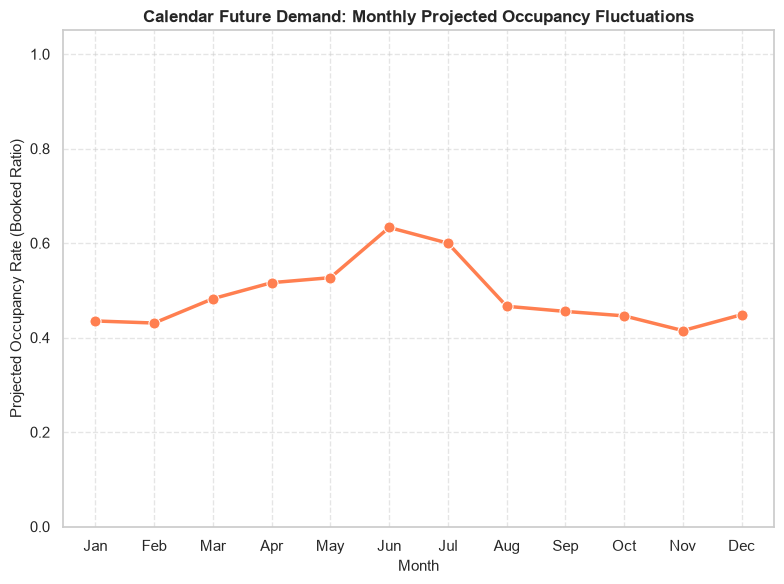

In [144]:
# 7. Render Plot
if len(monthly_seasonality) > 0:
    plt.figure(figsize=(8, 6))
    sns.lineplot(
        data=monthly_seasonality,
        x='month',
        y='avg_booked_rate',
        marker='o',
        markersize=8,
        color='coral',
        linewidth=2.5
    )
    plt.title('Calendar Future Demand: Monthly Projected Occupancy Fluctuations', fontsize=12, fontweight='bold')
    plt.xlabel('Month', fontsize=11)
    plt.ylabel('Projected Occupancy Rate (Booked Ratio)', fontsize=11)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Date column could not be parsed. Check raw sample printed above in Step 1.")

C:\Users\prajw\AppData\Local\Temp\ipykernel_17256\2465363156.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


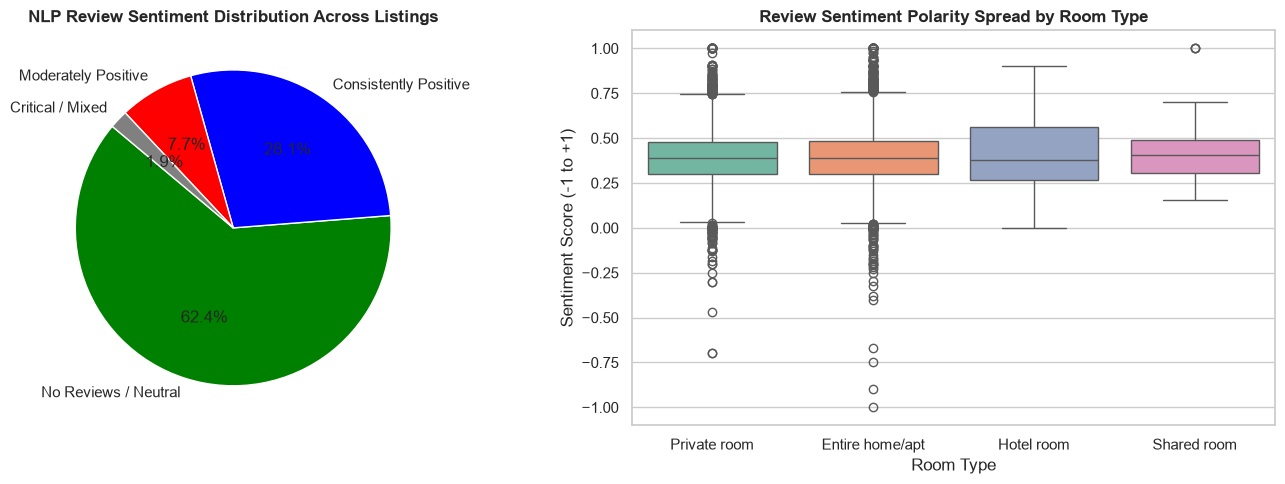

In [115]:
# Sentiment Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sentiment Category Pie Chart
df_listings['sentiment_category'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=['green', 'blue', 'red', 'gray'],
    ax=ax1,
)
ax1.set_title(
    'NLP Review Sentiment Distribution Across Listings',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('')

# 2. Sentiment Polarity by Room Type
sns.boxplot(
    data=df_listings[
        df_listings['sentiment_category'] != 'No Reviews / Neutral'
    ],
    x='room_type',
    y='avg_sentiment_score',
    palette='Set2',
    ax=ax2,
)
ax2.set_title(
    'Review Sentiment Polarity Spread by Room Type',
    fontsize=12,
    fontweight='bold',
)
ax2.set_xlabel('Room Type')
ax2.set_ylabel('Sentiment Score (-1 to +1)')

plt.tight_layout()
plt.show()

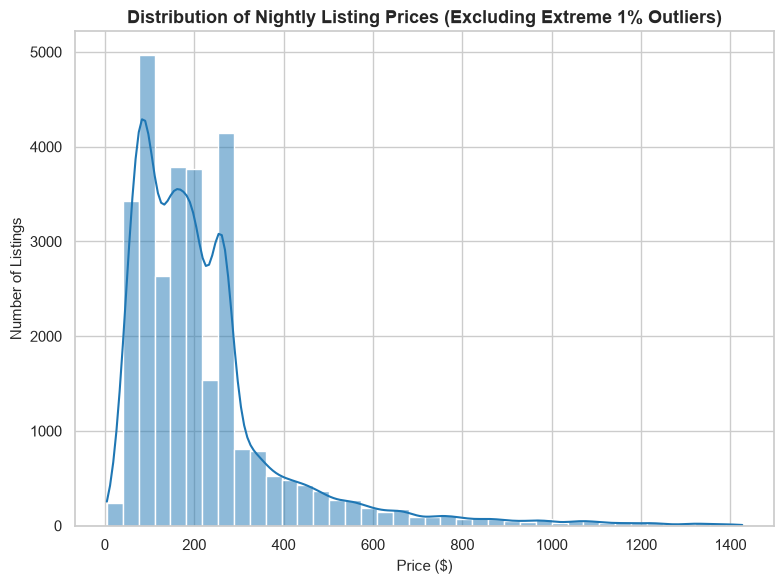

In [146]:
# Chart 1 - Distribution of Listing Prices
plt.figure(figsize=(8,6))
sns.histplot(df_cleaned['price'], bins=40, kde=True, color='#1f77b4')
plt.title(
    'Distribution of Nightly Listing Prices (Excluding Extreme 1% Outliers)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Price ($)', fontsize=11)
plt.ylabel('Number of Listings', fontsize=11)
plt.tight_layout()
plt.show()

Top 10 Neighborhoods Data:


,neighbourhood,count
0,Bedford-Stuyvesant,2087
1,Midtown,1735
2,Williamsburg,1512
3,Harlem,1401
4,Hell's Kitchen,1352
5,Upper West Side,1181
6,Upper East Side,1153
7,Bushwick,1016
8,Crown Heights,871
9,Chelsea,722


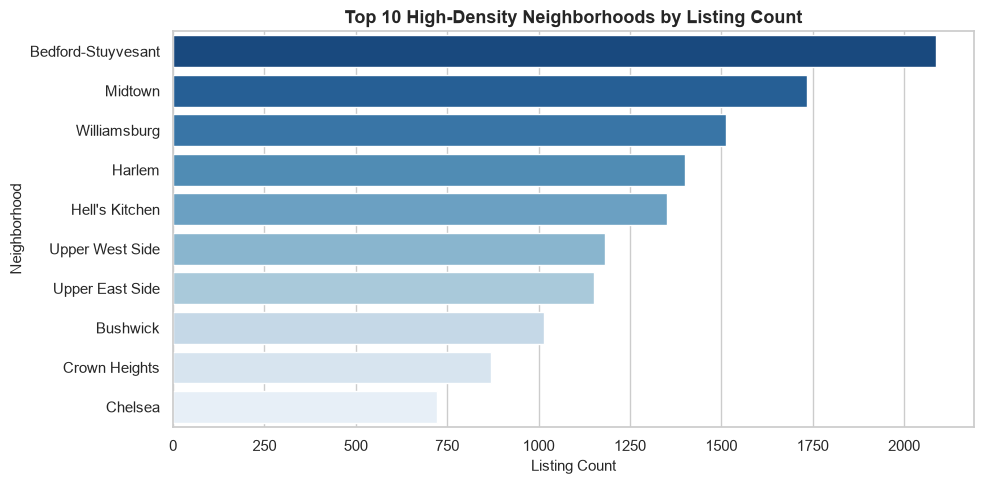

In [154]:
# Chart 2 - Count of properties per top neighborhood

# 1. Populate 'neighbourhood' from 'neighbourhood_cleansed'
if 'neighbourhood_cleansed' in df_raw.columns:
    df_cleaned['neighbourhood'] = df_raw.loc[df_cleaned.index, 'neighbourhood_cleansed']

# 2. Compute top 10 neighborhoods
top_10_neigh = df_cleaned['neighbourhood'].value_counts().head(10).reset_index()
top_10_neigh.columns = ['neighbourhood', 'count']

print("Top 10 Neighborhoods Data:")
display(top_10_neigh)

# 3. Render Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_10_neigh, 
    x='count', 
    y='neighbourhood', 
    palette='Blues_r',
    hue='neighbourhood',
    legend=False
)
plt.title('Top 10 High-Density Neighborhoods by Listing Count', fontsize=13, fontweight='bold')
plt.xlabel('Listing Count', fontsize=11)
plt.ylabel('Neighborhood', fontsize=11)
plt.tight_layout()
plt.show()

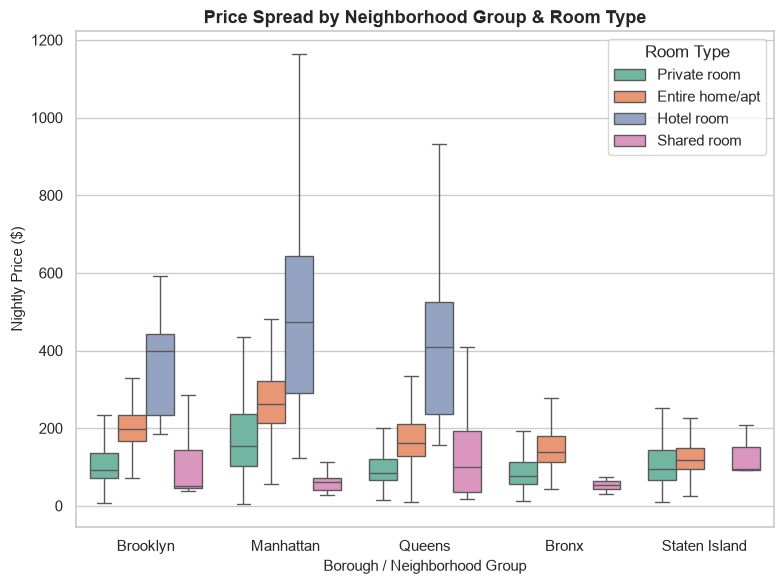

In [ ]:
# Chart 3 - Boxplot of price ranges across boroughs and room types
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_cleaned,
    x='neighbourhood_group',
    y='price',
    hue='room_type',
    showfliers=False,
    palette='Set2',
)
plt.title(
    'Price Spread by Neighborhood Group & Room Type',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Borough / Neighborhood Group', fontsize=11)
plt.ylabel('Nightly Price ($)', fontsize=11)
plt.legend(title='Room Type', loc='upper right')
plt.tight_layout()
plt.show()

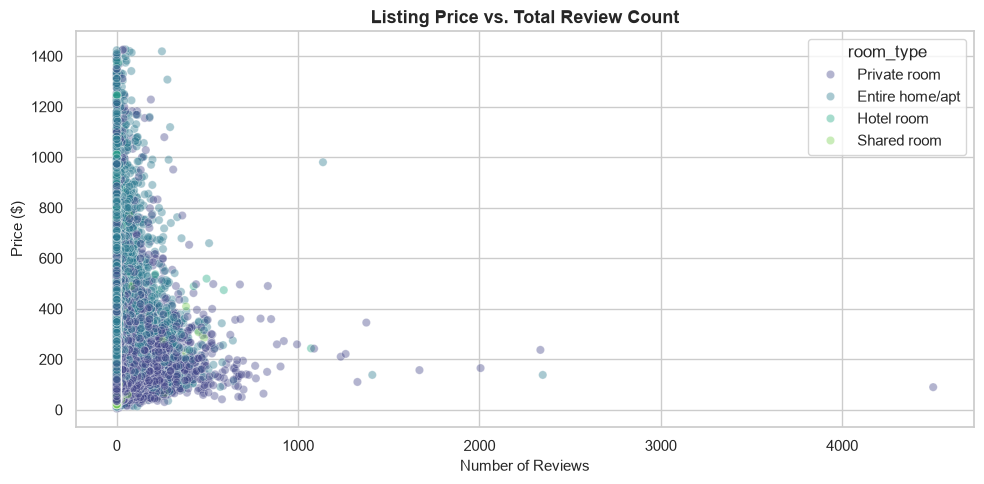

In [ ]:
#  Chart 4 - Scatter plot showing price vs. review engagement
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_cleaned,
    x='number_of_reviews',
    y='price',
    hue='room_type',
    alpha=0.4,
    palette='viridis',
)
plt.title(
    'Listing Price vs. Total Review Count', fontsize=13, fontweight='bold'
)
plt.xlabel('Number of Reviews', fontsize=11)
plt.ylabel('Price ($)', fontsize=11)
plt.tight_layout()
plt.show()

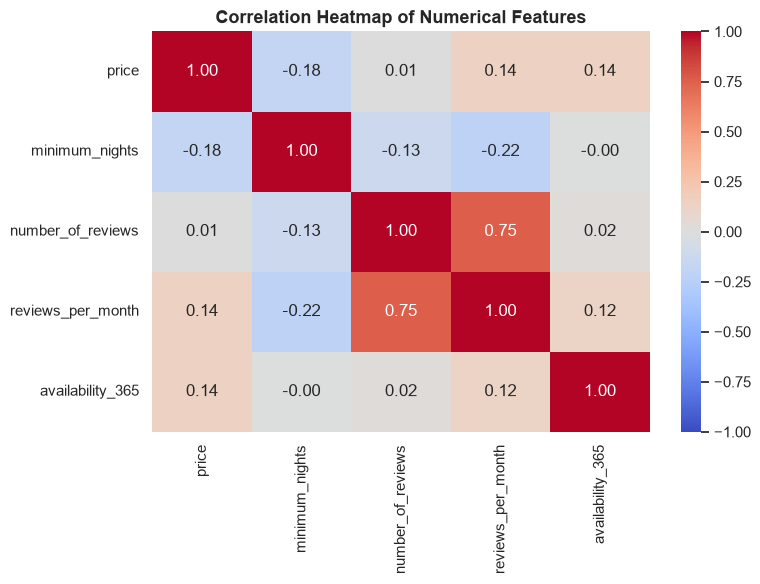

In [151]:
# Chart 5 - Correlation matrix of numerical variables
plt.figure(figsize=(8, 6))
num_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'review_scores_rating',
]
corr_matrix = df_cleaned[
    [c for c in num_cols if c in df_cleaned.columns]
].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar=True,
)
plt.title(
    'Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## FINAL CONSOLIDATION CELL: Build master dataset from df_cleaned

In [157]:
# 1. Ensure neighbourhood is fully populated in df_cleaned
if 'neighbourhood_cleansed' in df_raw.columns:
  df_cleaned['neighbourhood'] = df_raw.loc[
      df_cleaned.index, 'neighbourhood_cleansed'
  ]

In [158]:
# 2. Attach Sentiment Analysis (from sentiment_per_listing)
df_cleaned['id'] = df_cleaned['id'].astype('Int64')
sentiment_per_listing['listing_id'] = sentiment_per_listing['listing_id'].astype(
    'Int64'
)

# Merge sentiment columns
df_final = df_cleaned.merge(
    sentiment_per_listing[[
        'listing_id',
        'avg_sentiment_score',
        'total_comments_analyzed',
        'sentiment_category',
    ]],
    left_on='id',
    right_on='listing_id',
    how='left',
).drop(columns=['listing_id'])

# Impute listings without reviews
df_final['sentiment_category'] = df_final['sentiment_category'].fillna(
    'No Reviews / Neutral'
)
df_final['avg_sentiment_score'] = df_final['avg_sentiment_score'].fillna(0.0)

In [159]:
# 3. Attach Calendar Future Occupancy (from cal_valid)

# Group cal_valid by listing_id to get future booked nights
cal_valid['listing_id'] = pd.to_numeric(
    cal_valid['listing_id'], errors='coerce'
).astype('Int64')

occ_per_listing = (
    cal_valid.groupby('listing_id')['is_booked']
    .agg(booked_nights='sum', total_tracked_nights='count')
    .reset_index()
)
occ_per_listing['future_occupancy_rate'] = (
    occ_per_listing['booked_nights'] / occ_per_listing['total_tracked_nights']
).round(4)

# Merge occupancy rate
df_final = df_final.merge(
    occ_per_listing[['listing_id', 'future_occupancy_rate']],
    left_on='id',
    right_on='listing_id',
    how='left',
).drop(columns=['listing_id'])

# Fallback for properties not tracked in calendar
df_final['future_occupancy_rate'] = (
    df_final['future_occupancy_rate']
    .fillna((365 - df_final['availability_365']) / 365.0)
    .clip(0, 1)
)

In [160]:
# 4. Attach review_scores_rating from df_raw for KPI scoring
if 'review_scores_rating' in df_raw.columns:
  df_final['review_scores_rating'] = df_raw.loc[
      df_final.index, 'review_scores_rating'
  ].fillna(4.7)

# 5. Export to CSV for Streamlit
df_final.to_csv(r'C:\aFiles And Media\DataAnalytics\HexaSolutions\Hexa Assignments\Assignments To Submit 09-10-2026\Airbnb Data Analysis and Dashboard Creation\master_airbnb_cleaned.csv', index=False)

print(
    f"Success! Master dataset saved to 'master_airbnb_cleaned.csv' with"
    f' {len(df_final):,} rows and {df_final.shape[1]} columns.'
)
display(
    df_final[[
        'id',
        'name',
        'neighbourhood',
        'price',
        'sentiment_category',
        'future_occupancy_rate',
    ]].head(5)
)

Success! Master dataset saved to 'master_airbnb_cleaned.csv' with 29,956 rows and 17 columns.


,id,name,neighbourhood,price,sentiment_category,future_occupancy_rate
0,2539,11 Min to Manhattan • Prospect Park • Fast WiFi,Kensington,113.97,Consistently Positive,0.07
1,6848,Only 2 stops to Manhattan studio,Williamsburg,117.27,Consistently Positive,0.48
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),East Harlem,80.06,Consistently Positive,0.22
3,6990,UES Beautiful Blue Room,East Harlem,77.17,Consistently Positive,0.40
4,7097,"Perfect for Your Parents, With Garden & Patio",Fort Greene,202.47,Consistently Positive,0.71
